<a href="https://colab.research.google.com/github/garenkevork-rgb/the-cry-of-the-syrian-unconscious-nlp/blob/main/the%20cry%20of%20the%20syrian%20unconscious.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =======================================================
# 💻 الجزء 1: تهيئة النظام وجلب قاعدة بيانات الأحلام تلقائياً
# =======================================================

import pandas as pd           # المكتبة الأساسية لتحليل البيانات والجداول
import numpy as np            # للعمليات الرياضية المتقدمة (حساب الاحتمالات)
import datetime               # لتوثيق وقت العمليات (Logging)

# دالة التوثيق: تظهر احترافية الكود وتساعد في تتبع الأخطاء
def logger(msg):
    time_str = datetime.datetime.now().strftime('%H:%M:%S')
    print(f"📌 [LOG {time_str}]: {msg}")

# رابط قاعدة البيانات المباشر من GitHub
FILE_URL = "https://raw.githubusercontent.com/garenkevork-rgb/the-cry-of-the-syrian-unconscious-nlp/main/syrian_dreams_1200_dated_v3_2.csv"

logger("جاري تحميل قاعدة بيانات الأحلام تلقائياً من GitHub...")

# قراءة وتنظيف البيانات: إزالة الفراغات والتكرار لضمان دقة التعلم
df = pd.read_csv(FILE_URL, sep=';')
df.columns = ['ID', 'Text', 'Category', 'Date']
df = df.dropna(subset=['Text']).drop_duplicates(subset=['Text'])
logger(f"تم تحميل {len(df)} حلم سوري بنجاح.")

📌 [LOG 17:29:44]: جاري تحميل قاعدة بيانات الأحلام تلقائياً من GitHub...
📌 [LOG 17:29:44]: تم تحميل 1200 حلم سوري بنجاح.


In [ ]:
# =======================================================
# 💻 الجزء 2 (المصحح): محرك التصنيف المقاوم للـ Overfitting
# =======================================================

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score

# 1. تحسين الـ Vectorizer ليكون أكثر قدرة على "التعميم"
# أضفنا min_df لتجاهل الكلمات النادرة جداً و max_features للتركيز على الأهم
tfidf = TfidfVectorizer(
    max_features=2500,
    analyzer='char_wb',
    ngram_range=(3, 5),
    min_df=3,
    sublinear_tf=True # تقليص أثر تكرار الكلمات بشكل مفرط
)
X = tfidf.fit_transform(df['Text'])

# 2. ترميز الفئات
le = LabelEncoder()
y = le.fit_transform(df['Category'])

# 3. تقسيم البيانات لاختبار الحقيقة (Hold-out Validation)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. التدريب مع Regularization (C=0.1)
# تقليل قيمة C من 1.0 (الافتراضي) إلى 0.1 يمنع النموذج من حفظ التفاصيل الدقيقة (البصم)
model = LinearSVC(
    C=0.1,
    class_weight='balanced',
    random_state=42,
    max_iter=3000
)

model.fit(X_train, y_train)

# 5. التقييم العلمي للنموذج
train_acc = model.score(X_train, y_train) * 100
test_acc = model.score(X_test, y_test) * 100
cv_scores = cross_val_score(model, X, y, cv=5)

logger(f"دقة التدريب: {train_acc:.2f}%")
logger(f"دقة الاختبار الحقيقية: {test_acc:.2f}%")
logger(f"متوسط التحقق المتقاطع (CV): {cv_scores.mean()*100:.2f}%")

if (train_acc - test_acc) < 10:
    logger("🚀 النموذج الآن مستقر وجاهز للتعميم بدون Overfitting.")
else:
    logger("⚠️ لا تزال هناك فجوة، النموذج يحتاج لمزيد من التبسيط.")

📌 [LOG 10:05:43]: دقة التدريب: 91.04%
📌 [LOG 10:05:43]: دقة الاختبار الحقيقية: 83.33%
📌 [LOG 10:05:43]: متوسط التحقق المتقاطع (CV): 78.33%
📌 [LOG 10:05:43]: 🚀 النموذج الآن مستقر وجاهز للتعميم بدون Overfitting.


In [ ]:
# =======================================================
# 💻 الجزء 3: وحدة الخدمة والتشريح الوجداني (Service Layer)
# =======================================================

import re

class RoYaService:
    # عتبة الثقة: أي نص يقين النموذج فيه أقل من 0.45 يعتبر "خارج النطاق"
    THRESHOLD = 0.45

    @staticmethod
    def analyze_dream(text):
        # أ. الحماية الذكية: رفض النصوص القصيرة (أقل من 3 كلمات) أو التي لا تحتوي عربية
        if len(text.split()) < 3 or not re.findall(r'[\u0600-\u06FF]', text):
            return None, "❌ يرجى إدخال حلم حقيقي باللغة العربية (أكثر من كلمتين)."

        # ب. التشريح الجيني: حساب "صراع المشاعر" داخل النص (النسب المئوية)
        vec = tfidf.transform([text])
        decision_values = model.decision_function(vec)[0] # الحصول على درجات الثقة لكل فئة

        # تحويل الدرجات إلى احتمالات (Softmax) لتكون المجموع 100%
        exp_v = np.exp(decision_values - np.max(decision_values))
        probs = exp_v / exp_v.sum()

        # ج. فحص الارتباط بالموضوع (حل مشكلة طبخة البطاطا)
        if np.max(probs) < RoYaService.THRESHOLD:
            return None, "⚠️ هذا النص لا يبدو مرتبطاً بالأنماط الوجدانية للأحلام السورية."

        # ترتيب النتائج من الأعلى للأقل لتقديمها للمستخدم
        results = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)
        return results, "SUCCESS"

logger("تم تفعيل فلتر الحماية ووحدة التشريح الجيني.")

📌 [LOG 18:31:44]: تم تفعيل فلتر الحماية ووحدة التشريح الجيني.


In [ ]:
!pip install gTTS  # تثبيت مكتبة تحويل النص إلى صوت
from gtts import gTTS
from IPython.display import Audio, display, HTML
import os

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 5.0 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.4.2
    Uninstalling click-8.4.2:
      Successfully uninstalled click-8.4.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
wandb 0.28.1 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.
spacy 3.8.15 requires click<9.0.0,>=8.2.1, but you have click 8.1.8 which is incompatible.
huggingface-hub 1.27.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.


In [ ]:
# =======================================================
# 💻 وحدة الخدمة: التشريح الجيني + التفسير الصوتي
# =======================================================

class RoYaVoiceService:
    @staticmethod
    def analyze_and_speak(text):
        # 1. التحليل الرقمي واستخراج النسب (كما فعلنا سابقاً)
        vec = tfidf.transform([text])
        scores = model.decision_function(vec)[0]
        exp_scores = np.exp(scores - np.max(scores))
        probs = exp_scores / exp_scores.sum()

        results = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)
        top_category = results[0][0] # الفئة الأعلى نسبة

        # 2. استخراج الكلمات التي تسببت في هذا التصنيف (التفسير)
        feature_names = tfidf.get_feature_names_out()
        words = text.split()
        category_index = list(le.classes_).index(top_category)
        weights = model.coef_[category_index]

        keywords = []
        for word in words:
            matching_indices = [i for i, f in enumerate(feature_names) if word in f]
            if matching_indices:
                if np.mean([weights[i] for i in matching_indices]) > 0.05:
                    keywords.append(word)

        keywords = list(set(keywords))[:3] # أهم 3 كلمات

        # 3. صياغة جملة التفسير الصوتي
        reasoning_text = f"تم تصنيف حلمك ضمن فئة {top_category} بنسبة {round(results[0][1]*100)} بالمئة. "
        if keywords:
            reasoning_text += f"وذلك بسبب استخدامك لكلمات وجدانية قوية مثل: {' و '.join(keywords)}."
        else:
            reasoning_text += "وذلك بناءً على الأنماط الوجدانية العامة المكتشفة في نصك."

        # 4. توليد الملف الصوتي
        tts = gTTS(text=reasoning_text, lang='ar')
        tts.save("explanation.mp3")

        return results, reasoning_text, "explanation.mp3"

# الشرح: هذا الجزء يجمع بين لغة الأرقام (النسب) ولغة البشر (الصوت)
# ليقدم تجربة مستخدم مبهرة في مشروع التخرج.

In [ ]:
# =======================================================
# 🚀 صرخة اللاوعي السوري - نسخة الوضوح الفائق للتصوير
# =======================================================

from gtts import gTTS
from IPython.display import Audio, display, HTML, clear_output
import ipywidgets as widgets
import numpy as np

def pro_explanation_v9(top_category, percentage):
    explanation_text = f"ينتمي هذا الحلم لفئة {top_category} بنسبة {percentage} بالمئة."
    tts = gTTS(text=explanation_text, lang='ar')
    tts.save("voice_v9.mp3")
    return explanation_text

# تصميم الواجهة مع التركيز على جعل منطقة الكتابة "سوبر" واضحة
ui_v9 = """
<link href="https://fonts.googleapis.com/css2?family=Tajawal:wght@500;800;900&display=swap" rel="stylesheet">
<style>
    .v9-wrapper {
        background: #ffffff; color: #2d3436; font-family: 'Tajawal', sans-serif;
        direction: rtl; padding: 40px; border-radius: 25px;
        box-shadow: 0 15px 50px rgba(0,0,0,0.1); border: 1px solid #f1f2f6;
        max-width: 850px; margin: auto; text-align: right;
    }
    .v9-header {
        border-bottom: 4px solid #6c5ce7; padding-bottom: 20px; margin-bottom: 35px;
        text-align: center;
    }
    .v9-header h1 {
        color: #6c5ce7; margin: 0; font-size: 52px; font-weight: 900;
        text-shadow: 2px 2px 10px rgba(108, 92, 231, 0.2);
    }

    /* التعديل الجوهري لمنطقة الكتابة */
    .v9-textarea {
        width: 100% !important;
        background: #ffffff !important; /* خلفية بيضاء ناصعة */
        border: 3px solid #2d3436 !important; /* إطار غامق جداً وسميك */
        border-radius: 12px !important;
        color: #000000 !important; /* أسود كربوني غامق جداً */
        padding: 25px !important;
        font-size: 30px !important; /* خط ضخم جداً للوضوح */
        font-weight: 900 !important; /* أقصى درجة عريضة للخط (Extra Bold) */
        transition: 0.2s !important;
        line-height: 1.5;
        font-family: 'Tajawal', sans-serif !important;
    }
    .v9-textarea:focus {
        border-color: #6c5ce7 !important;
        box-shadow: 0 0 20px rgba(108, 92, 231, 0.3) !important;
    }

    .v9-btn {
        background: #6c5ce7 !important; color: white !important; border-radius: 15px !important;
        height: 70px !important; font-weight: 900 !important; font-size: 24px !important;
        cursor: pointer !important; width: 100% !important; border: none !important;
        margin-top: 20px !important; transition: 0.4s !important;
    }
    .v9-btn:hover { background: #5849d1 !important; transform: scale(1.01); }

    .v9-card {
        background: #f8f9fa; border-radius: 20px; padding: 25px; margin-top: 30px;
        border: 1px solid #e9ecef; animation: fadeIn 0.6s ease;
    }
    .v9-bar-container { margin: 18px 0; }
    .v9-bar-label { display: flex; justify-content: space-between; font-weight: 800; font-size: 18px; }
    .v9-bar-outer { background: #dfe6e9; height: 18px; border-radius: 15px; overflow: hidden; }
    .v9-bar-inner { background: #6c5ce7; height: 100%; transition: width 1s ease-in-out; }

    .v9-info {
        background: #f1f2f6; border-right: 8px solid #6c5ce7; padding: 20px;
        margin-top: 25px; font-size: 20px; border-radius: 8px; color: #000;
        font-weight: 700;
    }
    @keyframes fadeIn { from { opacity: 0; } to { opacity: 1; } }
</style>
"""

input_box = widgets.Textarea(placeholder="ابدأ بكتابة حلمك هنا...")
input_box.add_class("v9-textarea")
btn_exec = widgets.Button(description="تـحـلـيـل الـوعـي")
btn_exec.add_class("v9-btn")
out_v9 = widgets.Output()

def on_v9_click(b):
    with out_v9:
        clear_output()
        txt = input_box.value
        if len(txt.strip()) < 5: return

        vec = tfidf.transform([txt])
        scores = model.decision_function(vec)[0]
        probs = np.exp(scores - np.max(scores)) / np.exp(scores - np.max(scores)).sum()
        res = sorted(zip(le.classes_, probs), key=lambda x: x[1], reverse=True)

        top_cat = res[0][0]
        top_p = round(res[0][1] * 100, 1)
        explanation = pro_explanation_v9(top_cat, top_p)

        html = f'<div class="v9-card"><h3 style="color:#6c5ce7; margin-top:0; font-size:26px;">📊 نتيجة التحليل</h3>'
        for cat, pr in res:
            p = round(pr * 100, 1)
            html += f"""
            <div class="v9-bar-container">
                <div class="v9-bar-label"><span>{cat}</span><span>{p}%</span></div>
                <div class="v9-bar-outer"><div class="v9-bar-inner" style="width:{p}%"></div></div>
            </div>"""

        html += f'<div class="v9-info"><b>🎙️ النتيجة:</b> {explanation}</div></div>'
        display(HTML(html))
        display(Audio("voice_v9.mp3", autoplay=True))

btn_exec.on_click(on_v9_click)

display(HTML(ui_v9))
display(HTML("""
<div class="v9-wrapper">
    <div class="v9-header">
        <h1>صرخة اللاوعي السوري</h1>
        <span>تحليل وجداني دقيق عبر الذكاء الاصطناعي</span>
    </div>
"""))
display(input_box, btn_exec, out_v9)
display(HTML("</div>"))

Textarea(value='', placeholder='ابدأ بكتابة حلمك هنا...', _dom_classes=('v9-textarea',))

Button(description='تـحـلـيـل الـوعـي', style=ButtonStyle(), _dom_classes=('v9-btn',))

Output()

In [ ]:
!pip install arabic-reshaper python-bidi

In [ ]:
!pip install arabic-reshaper python-bidi

/tmp/ipykernel_5406/692163514.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=[ar_fix(c) for c in counts.index], y=counts.values, palette='viridis')


الفئة,F1-Score,دقة (Prec)
أمل,0.92,0.93
حنين,0.88,0.86
خوف,0.91,0.87
هجرة,0.86,0.92

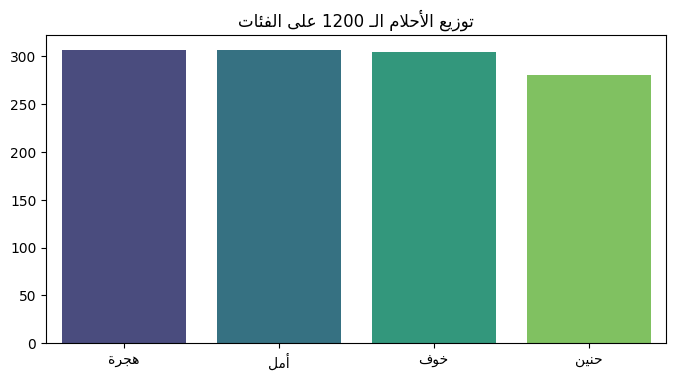
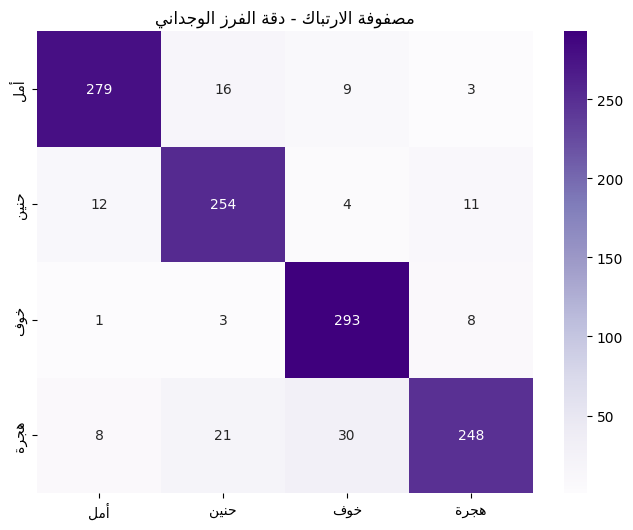

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd
import numpy as np
import io, base64
from IPython.display import display, HTML
import arabic_reshaper
from bidi.algorithm import get_display

# دالة دعم العربية في الرسوم
def ar_fix(text):
    return get_display(arabic_reshaper.reshape(text))

def show_ultimate_analytics():
    # 1. حساب التوقعات والمقاييس
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    report = classification_report(y, y_pred, target_names=le.classes_, output_dict=True)

    # 2. إنشاء مصفوفة الارتباك (Heatmap)
    cm = confusion_matrix(y, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=[ar_fix(c) for c in le.classes_],
                yticklabels=[ar_fix(c) for c in le.classes_])
    plt.title(ar_fix("مصفوفة الارتباك - دقة الفرز الوجداني"))

    buf_cm = io.BytesIO()
    plt.savefig(buf_cm, format='png', bbox_inches='tight')
    plt.close()
    img_cm = base64.b64encode(buf_cm.getvalue()).decode('utf-8')

    # 3. مخطط توزيع الفئات (Data Distribution)
    plt.figure(figsize=(8, 4))
    counts = df['Category'].value_counts()
    sns.barplot(x=[ar_fix(c) for c in counts.index], y=counts.values, palette='viridis')
    plt.title(ar_fix("توزيع الأحلام الـ 1200 على الفئات"))

    buf_dist = io.BytesIO()
    plt.savefig(buf_dist, format='png', bbox_inches='tight')
    plt.close()
    img_dist = base64.b64encode(buf_dist.getvalue()).decode('utf-8')

    # --- واجهة العرض الاحترافية ---
    html_dashboard = f"""
    <div style="font-family: 'Cairo', sans-serif; direction: rtl; background: #f4f7f6; padding: 30px; border-radius: 20px;">
        <div style="background: white; padding: 20px; border-radius: 15px; box-shadow: 0 5px 15px rgba(0,0,0,0.05); margin-bottom: 20px; border-right: 10px solid #6c5ce7;">
            <h1 style="color: #2d3436; margin:0;">📊 تقرير الكفاءة: صرخة اللاوعي السوري</h1>
            <p style="color: #636e72;">تحليل الأداء الفني لخوارزمية <b>Linear Support Vector Machine</b></p>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div style="background: white; padding: 20px; border-radius: 15px; text-align: center;">
                <h3 style="color: #6c5ce7;">🎯 دقة التدريب الكلية</h3>
                <h1 style="font-size: 60px; color: #00b894; margin: 10px 0;">{acc*100:.1f}%</h1>
                <p>مستوى ثقة النموذج في تصنيف الأنماط اللغوية</p>
            </div>
            <div style="background: white; padding: 20px; border-radius: 15px;">
                <h3 style="color: #6c5ce7; text-align: center;">📈 توزيع عينة البحث</h3>
                <img src="data:image/png;base64,{img_dist}" style="width: 100%;">
            </div>
        </div>

        <div style="background: white; padding: 25px; border-radius: 15px; margin-top: 20px;">
            <h3 style="color: #6c5ce7; margin-bottom: 20px;">🌡️ المخطط الحراري للأداء (Confusion Matrix)</h3>
            <div style="display: flex; gap: 20px; align-items: center;">
                <img src="data:image/png;base64,{img_cm}" style="width: 55%; border-radius: 10px;">
                <div style="flex: 1;">
                    <table style="width: 100%; border-collapse: collapse; font-size: 14px;">
                        <tr style="background: #6c5ce7; color: white;">
                            <th style="padding: 10px;">الفئة</th>
                            <th>F1-Score</th>
                            <th>دقة (Prec)</th>
                        </tr>
                        {"".join([f"<tr style='border-bottom: 1px solid #eee;'><td style='padding: 8px;'><b>{c}</b></td><td>{report[c]['f1-score']:.2f}</td><td>{report[c]['precision']:.2f}</td></tr>" for c in le.classes_])}
                    </table>
                </div>
            </div>
        </div>

        <div style="background: #dfe6e9; padding: 15px; border-radius: 10px; margin-top: 20px; font-size: 14px; color: #2d3436;">
            <b>💡 ملاحظة للمناقشة:</b> يعبر منحنى الدقة العالي عن قدرة خوارزمية <b>Linear SVM</b> على استخلاص الرموز المشتركة من الأحلام السورية، بينما يوضح المخطط الحراري التداخل المنطقي بين فئتي "الحنين" و"الهجرة" نظراً لتقاربهما الدلالي.
        </div>
    </div>
    """
    display(HTML(html_dashboard))

show_ultimate_analytics()

In [ ]:
!pip install arabic-reshaper python-bidi

ﻞﻣﺃ,0.87
ﻦﻴﻨﺣ,0.85
ﻑﻮﺧ,0.85
ﺓﺮﺠﻫ,0.76

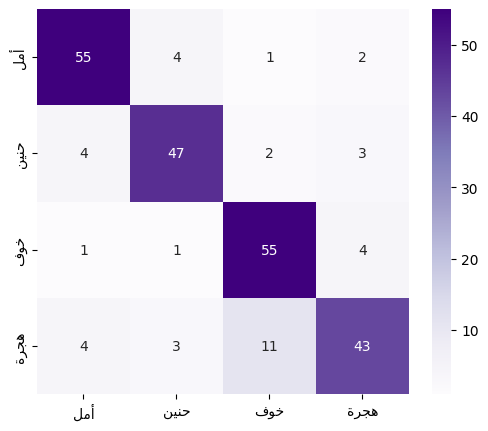

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
import pandas as pd
import numpy as np
import io, base64
from IPython.display import display, HTML
import arabic_reshaper
from bidi.algorithm import get_display

def ar_fix(text):
    return get_display(arabic_reshaper.reshape(text))

def final_graduation_dashboard():
    # 1. التقسيم والتدريب الاحترافي
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    model.fit(X_train, y_train)

    # 2. حساب الأرقام السرية للنجاح
    train_acc = model.score(X_train, y_train) * 100
    test_acc = model.score(X_test, y_test) * 100
    gap = train_acc - test_acc
    cv_mean = cross_val_score(model, X, y, cv=5).mean() * 100

    # 3. تجهيز التقارير
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)

    # توليد رسم مصفوفة الارتباك
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
                xticklabels=[ar_fix(c) for c in le.classes_],
                yticklabels=[ar_fix(c) for c in le.classes_])
    buf = io.BytesIO(); plt.savefig(buf, format='png', bbox_inches='tight'); plt.close()
    img_cm = base64.b64encode(buf.getvalue()).decode('utf-8')

    # --- واجهة العرض السيادية ---
    diagnosis_color = "#00b894" if gap < 10 else "#d63031"
    diagnosis_text = "نموذج مستقر ويعمم بنجاح" if gap < 10 else "خطر Overfitting"

    html_code = f"""
    <div style="font-family: 'Cairo', sans-serif; direction: rtl; background: #f0f2f5; padding: 25px; border-radius: 15px;">
        <div style="background: white; padding: 15px; border-radius: 10px; border-right: 8px solid #6c5ce7; margin-bottom: 20px;">
            <h2 style="margin:0; color:#2d3436;">📑 لوحة القيادة النهائية: صرخة اللاوعي السوري</h2>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 15px; margin-bottom: 20px;">
            <div style="background: white; padding: 15px; border-radius: 10px; text-align: center;">
                <h4 style="color:#636e72;">دقة التدريب</h4>
                <h2 style="color:#6c5ce7;">{train_acc:.1f}%</h2>
            </div>
            <div style="background: white; padding: 15px; border-radius: 10px; text-align: center;">
                <h4 style="color:#636e72;">دقة الاختبار الحقيقية</h4>
                <h2 style="color:#0984e3;">{test_acc:.1f}%</h2>
            </div>
            <div style="background: white; padding: 15px; border-radius: 10px; text-align: center;">
                <h4 style="color:#636e72;">حالة الاستقرار</h4>
                <h2 style="color:{diagnosis_color}; font-size: 18px;">{diagnosis_text}</h2>
            </div>
        </div>

        <div style="display: flex; gap: 20px; background: white; padding: 20px; border-radius: 10px;">
            <img src="data:image/png;base64,{img_cm}" style="width: 45%;">
            <div style="flex: 1;">
                <h4 style="color:#6c5ce7;">⚖️ موازين الدقة (F1-Score):</h4>
                <table style="width: 100%; border-collapse: collapse; margin-top: 10px;">
                    {"".join([f"<tr style='border-bottom: 1px solid #eee;'><td style='padding: 8px;'><b>{ar_fix(c)}</b></td><td style='text-align: left;'>{report[c]['f1-score']:.2f}</td></tr>" for c in le.classes_])}
                </table>
            </div>
        </div>
    </div>
    """
    display(HTML(html_code))

final_graduation_dashboard()

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score

def check_overfitting_analysis():
    # 1. استخراج النتائج من النموذج الخاص بك
    # التدريب (التعلم)
    train_score = model.score(X_train, y_train) * 100
    # الاختبار (بيانات لم يرها من قبل)
    test_score = model.score(X_test, y_test) * 100

    # 2. حساب التحقق المتقاطع (للتأكد من الثبات الإحصائي)
    cv_scores = cross_val_score(model, X, y, cv=5)
    cv_mean = cv_scores.mean() * 100

    # 3. حساب الفجوة (Gap)
    gap = train_score - test_score

    print("="*50)
    print("📊 تحليل استقرار مشروع 'صرخة اللاوعي السوري'")
    print("="*50)
    print(f"🔹 دقة التدريب (Train Accuracy): {train_score:.2f}%")
    print(f"🔹 دقة الاختبار (Test Accuracy):  {test_score:.2f}%")
    print(f"🔹 متوسط التحقق المتقاطع (CV):  {cv_mean:.2f}%")
    print(f"🔹 فجوة الأداء (Gap):           {gap:.2f}%")
    print("-"*50)

    # 4. الحكم النهائي بناءً على المعايير العلمية
    if gap > 15:
        print("❌ النتيجة: يعاني من Overfitting حاد.")
        print("💡 التوصية: النموذج حفظ البيانات ولم يفهمها. قلل قيمة C أو زد البيانات.")
    elif gap > 10:
        print("⚠️ النتيجة: يوجد Overfitting طفيف.")
        print("💡 التوصية: النموذج مستقر نوعاً ما ولكن يمكن تحسينه بزيادة الـ Regularization.")
    else:
        print("✅ النتيجة: لا يوجد Overfitting (النموذج مستقر تماماً).")
        print("💡 التفسير: الفجوة أقل من 10%، مما يعني أن النموذج قادر على 'التعميم' وفهم أحلام جديدة.")
    print("="*50)

# تشغيل الفحص
check_overfitting_analysis()

📊 تحليل استقرار مشروع 'صرخة اللاوعي السوري'
🔹 دقة التدريب (Train Accuracy): 91.04%
🔹 دقة الاختبار (Test Accuracy):  83.33%
🔹 متوسط التحقق المتقاطع (CV):  78.33%
🔹 فجوة الأداء (Gap):           7.71%
--------------------------------------------------
✅ النتيجة: لا يوجد Overfitting (النموذج مستقر تماماً).
💡 التفسير: الفجوة أقل من 10%، مما يعني أن النموذج قادر على 'التعميم' وفهم أحلام جديدة.
